X shape: (70000, 784)
y shape: (70000,)
Epoch 1/10 | Train Loss: 0.3717 | Train Acc: 88.25% | Valid Acc: 88.14%
Epoch 2/10 | Train Loss: 0.2435 | Train Acc: 92.73% | Valid Acc: 93.21%
Epoch 3/10 | Train Loss: 0.1960 | Train Acc: 94.10% | Valid Acc: 93.91%
Epoch 4/10 | Train Loss: 0.2139 | Train Acc: 93.55% | Valid Acc: 93.09%
Epoch 5/10 | Train Loss: 0.1785 | Train Acc: 94.60% | Valid Acc: 94.81%
Epoch 6/10 | Train Loss: 0.1464 | Train Acc: 95.71% | Valid Acc: 95.41%
Epoch 7/10 | Train Loss: 0.1418 | Train Acc: 95.68% | Valid Acc: 95.07%
Epoch 8/10 | Train Loss: 0.1315 | Train Acc: 96.12% | Valid Acc: 95.75%
Epoch 9/10 | Train Loss: 0.1181 | Train Acc: 96.46% | Valid Acc: 95.25%
Epoch 10/10 | Train Loss: 0.1274 | Train Acc: 96.14% | Valid Acc: 95.43%


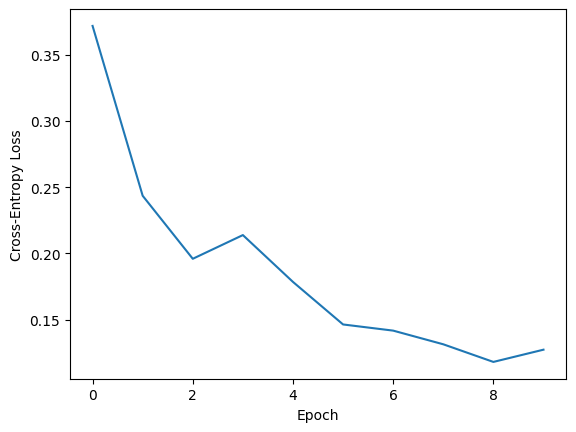

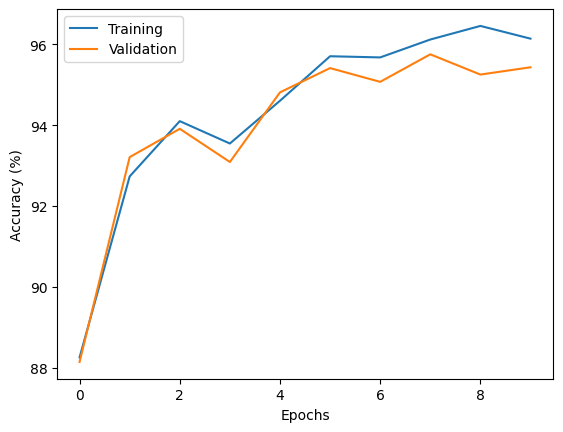

Test accuracy: 95.18%


In [ ]:
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
import numpy as np
import matplotlib.pyplot as plt

X, y = fetch_openml('mnist_784', version=1, return_X_y=True)
X = X.values.astype(np.float32)
y = y.astype(int).values
print("X shape:", X.shape)
print("y shape:", y.shape)

# Normalize pixels to [-1, 1]
X = (X / 255.0) * 2 - 1

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=10000, random_state=42, stratify=y)
X_train, X_valid, y_train, y_valid = train_test_split(X_temp, y_temp, test_size=5000, random_state=42, stratify=y_temp)



# ============================================
# Helper functions
# ============================================
def sigmoid(z):
    # Sigmoid activation
    z = np.clip(z, -500, 500)
    return 1 / (1 + np.exp(-z))

def softmax(z):
    # Softmax for probability distribution
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z= np.exp(z)
    return exp_z /np.sum(exp_z, axis=1 , keepdims=True)


def int_to_onehot(y, num_labels):
    # Convert labels to one-hot
    ary= np.zeros((y.shape[0], num_labels))
    for i, val in enumerate(y):
        ary[i, val] = 1

    return ary


def minibatch_generator(X, y, minibatch_size):
    # Generate mini-batches
    indices = np.arange(X.shape[0])
    np.random.shuffle(indices)
    for start_idx in range(0, indices.shape[0] - minibatch_size + 1, minibatch_size):
        batch_idx = indices[start_idx:start_idx + minibatch_size]
        yield X[batch_idx], y[batch_idx]


def cross_entropy_loss(targets, probas, num_labels=10):
    # Cross-entropy loss
    onehot_targets = int_to_onehot(targets , num_labels)
    eps = 1e-12
    probas = np.clip(probas, eps, 1. - eps)
    return -np.mean(np.sum(onehot_targets * np.log(probas), axis=1))


def accuracy(targets, predicted_labels):
    # Accuracy metric
    return np.mean(predicted_labels == targets)


def compute_loss_and_acc(nnet, X, y, minibatch_size=100):
    # Compute total loss and accuracy
    total_loss, correct_pred, num_examples = 0., 0, 0

    for features, targets in minibatch_generator(X, y, minibatch_size):
        _, probas = nnet.forward(features)
        predicted_labels = np.argmax(probas, axis=1)

        loss = cross_entropy_loss(targets, probas)

        total_loss += loss * targets.shape[0]
        correct_pred += np.sum(predicted_labels == targets)
        num_examples += targets.shape[0]

    return total_loss / num_examples, correct_pred / num_examples

# ============================================
# Define MLP model (1 hidden layer)
# ============================================
class NeuralNetMLP:
    def __init__(self, num_features, num_hidden, num_classes, random_seed=123):
        rng = np.random.RandomState(random_seed)
        self.num_classes = num_classes
        # Initialize weights
        self.weight_h = rng.normal(0.0, np.sqrt(1.0 / num_features), (num_features, num_hidden))
        self.bias_h = np.zeros((1, num_hidden))
        self.weight_out = rng.normal(0.0, np.sqrt(1.0 / num_hidden), (num_hidden, num_classes))
        self.bias_out = np.zeros((1, num_classes))

    def forward(self, x):
        # Hidden layer
        z_h = np.dot(x, self.weight_h) + self.bias_h
        a_h = sigmoid(z_h)
        # Output layer
        z_out = np.dot(a_h, self.weight_out) + self.bias_out
        a_out = softmax(z_out)
        return a_h, a_out

    def backward(self, x, a_h, a_out, y):
        y_onehot = int_to_onehot(y, self.num_classes)
        # Output delta (Softmax + CrossEntropy)
        delta_out = a_out - y_onehot
        d_loss__dw_out = np.dot(a_h.T, delta_out)
        d_loss__db_out = np.sum(delta_out, axis=0, keepdims=True)
        # Hidden delta
        delta_h = np.dot(delta_out, self.weight_out.T) * a_h * (1 - a_h)
        d_loss__d_w_h = np.dot(x.T, delta_h)
        d_loss__d_b_h = np.sum(delta_h, axis=0, keepdims=True)
        return d_loss__dw_out, d_loss__db_out, d_loss__d_w_h, d_loss__d_b_h


# ============================================
# Create model
# ============================================
model = NeuralNetMLP(num_features=28*28, num_hidden=50, num_classes=10)

# ============================================
# Train model with mini-batch gradient descent
# ============================================
def train(model, X_train, y_train, X_valid, y_valid, num_epochs, learning_rate=0.1, minibatch_size=128):
    epoch_loss, epoch_train_acc, epoch_valid_acc = [], [], []

    for e in range(num_epochs):
        minibatch_gen=minibatch_generator(X_train, y_train, minibatch_size)

        for X_batch, y_batch in minibatch_gen:
            a_h, a_out = model.forward(X_batch)
            dw_out, db_out, dw_h, db_h = model.backward(X_batch, a_h, a_out, y_batch)
            model.weight_h -= learning_rate * dw_h
            model.bias_h -= learning_rate * db_h
            model.weight_out -= learning_rate * dw_out
            model.bias_out -= learning_rate * db_out

        # Evaluate after each epoch
        train_loss, train_acc = compute_loss_and_acc(model, X_train, y_train, minibatch_size)
        valid_loss, valid_acc = compute_loss_and_acc(model, X_valid, y_valid, minibatch_size)

        epoch_loss.append(train_loss)
        epoch_train_acc.append(train_acc * 100)
        epoch_valid_acc.append(valid_acc * 100)

        print(f'Epoch {e+1}/{num_epochs} | Train Loss: {train_loss:.4f} | '
            f'Train Acc: {train_acc*100:.2f}% | Valid Acc: {valid_acc*100:.2f}%')

    return epoch_loss, epoch_train_acc, epoch_valid_acc

# ============================================
# Run training
# ============================================
np.random.seed(123)
epoch_loss, epoch_train_acc, epoch_valid_acc = train(
    model, X_train, y_train, X_valid, y_valid,
    num_epochs=10, learning_rate=0.01, minibatch_size=128
)

# Plot loss and accuracy
plt.plot(epoch_loss)
plt.ylabel('Cross-Entropy Loss')
plt.xlabel('Epoch')
plt.show()
plt.plot(epoch_train_acc, label='Training')
plt.plot(epoch_valid_acc, label='Validation')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epochs')
plt.legend()
plt.show()

# Evaluate on test set
test_loss, test_acc = compute_loss_and_acc(model, X_test, y_test)
print(f'Test accuracy: {test_acc*100:.2f}%')
